# Study Case - Session Duration vs. Calories Burned

- This study utilizes the Gym Members Exercise Tracking dataset, comprising records from 973 gym members.

- The primary objective is to examine the relationship between session duration (measured in hours) and calories burned.

- The methodology employed is Ordinary Least Squares (OLS), specifically a simple linear regression with a single predictor.

Simple regression built in this equation

$y=a+bx+\epsilon$

- y : output / outcome
- x : input variables / predictor 
- a : intercept
- b : slope 

- We need to import library and function that need to run the code in this notebook to:
  - load data
  - doing simulation
  - drawing graph and other visualization

In [1]:
# load data
import pandas as pd
import numpy as np

In [2]:
calories = pd.read_csv('gym_members_exercise_tracking.csv')
calories.head()

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake,Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:
calories.isnull().sum()

Age                              0
Gender                           0
Weight                           0
Height                           0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration                 0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake                     0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

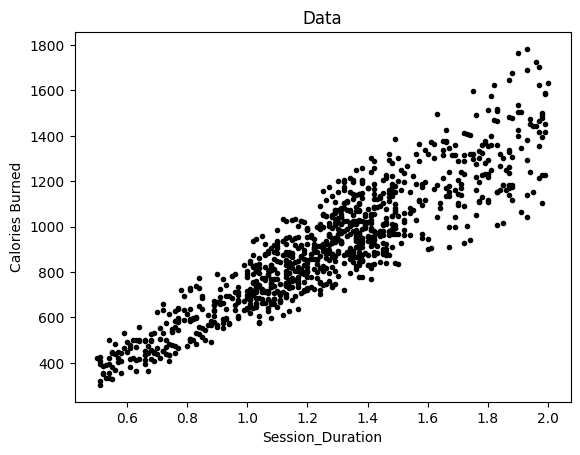

In [4]:
import matplotlib.pyplot as plt

x = calories['Session_Duration']
y = calories['Calories_Burned']

# Plot the data
plt.scatter(x, y, marker=".", color = "k")

# Add a legend and labels

plt.xlabel("Session_Duration")
plt.ylabel("Calories Burned")

# Add a title and adjust the margins
plt.title("Data")

# Show the plot
plt.show()

### Using Libary

Use ols function under statsmodel library as a convenience interface for specifying models using formula strings and DataFrames to calculate the estimated coefficient

In [5]:
# Import the library (use .formula so we can write the formula we want in the model)
import statsmodels.formula.api as smf

In [6]:
def print_coef_std_err(results):
    """
    Function to combine estimated coefficients and standard error in one DataFrame
    :param results: <statsmodels RegressionResultsWrapper> OLS regression results from 
    :return df: <pandas DataFrame> 
    """
    coef = results.params
    std_err = results.bse
    
    df = pd.DataFrame(data = np.transpose([coef, std_err]), 
                      index = coef.index, 
                      columns=["coef","std err"])
    return df

### Fit Linear Regression

In [7]:
# Create OLS model object
model = smf.ols("Calories_Burned ~ Session_Duration", data=calories)

# Fit the model
results = model.fit()

results_calories_burn = print_coef_std_err(results)

### The estimated coefficients and standard error

use `.params` to access the estimated coefficient from ols calculation

In [8]:
results.params

Intercept            -1.446459
Session_Duration    721.786016
dtype: float64

use `.bse` to access the standard errors of the estimated coefficients

In [9]:
results.bse

Intercept           13.907389
Session_Duration    10.678576
dtype: float64

- Visualize the data and regression line

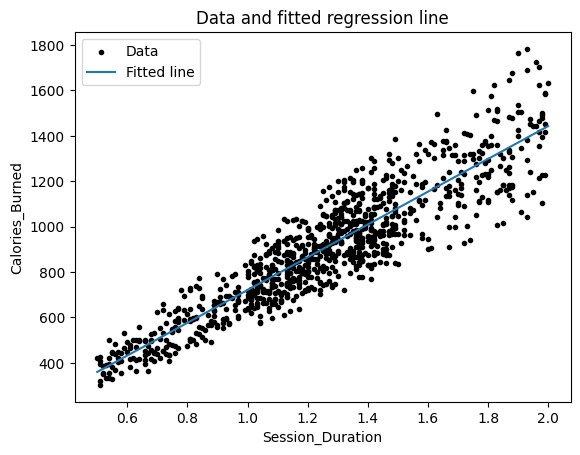

In [10]:
predictor = "Session_Duration"
outcome = "Calories_Burned"
data = calories.copy()
results_ = results_calories_burn.copy()

# Plot the data
plt.scatter(data[predictor], data[outcome], marker=".", label="Data", color = "k")

# Calculate the fitted values
a_hat = results_.loc["Intercept"]["coef"]
b_hat = results_.loc[predictor]["coef"]

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 10000)

fitted_values = a_hat + b_hat * x_domain

# Plot the fitted line
plt.plot(x_domain, fitted_values, label="Fitted line")

# Add a legend and labels
plt.legend()
plt.xlabel(f"{predictor}")
plt.ylabel(f"{outcome}")

# Add a title and adjust the margins
plt.title("Data and fitted regression line")

# Show the plot
plt.show()

### Coefficient Interpretation

In [11]:
results_calories_burn

,coef,std err
Intercept,-1.446459,13.907389
Session_Duration,721.786016,10.678576


$$y = -1.4465 + 721.7860 x$$

- 0 hour of exercise duration results in an average of -1.4465 calories burned (not meaningful in practice).
- Each additional 1 hour of exercise duration results in an average of ± 722 additional calories burned.

- We can write the equation equivalent to this to get easy way to interpret the intercept
$$y = 905.4 + 721.79 (x−1.3)$$

- When exercise duration equals the average (1.3 hours), the predicted calories burned is 905.4.
- Each additional 1 hour of exercise duration results in an average of 721.79 additional calories burned.

In [12]:
np.round(np.mean(calories["Session_Duration"]),1)

np.float64(1.3)

In [13]:
np.round(np.mean(calories["Calories_Burned"]),1)

np.float64(905.4)